## Time Series

# Time Series Analysis and Forecasting
    Last Updated : 19 Dec, 2025
    To understand how data changes over time, Time Series Analysis and Forecasting are used, which help track past patterns and predict future values. It is widely used in finance, weather, sales and sensor data.
    
    Focuses on data collected at regular time intervals
    Helps identify trends, seasonality and sudden changes
    Useful for planning, prediction and decision-making
    Common methods include ARIMA, exponential smoothing and machine learning models

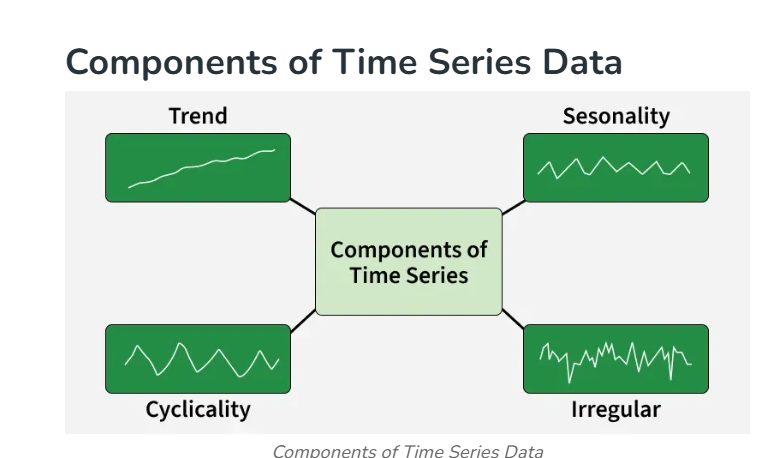

In [13]:
# !pip install datetime

In [14]:
from datetime import datetime

In [15]:
date_now=datetime.now()
date_now

datetime.datetime(2026, 7, 10, 21, 38, 36, 52462)

In [16]:
date_now.year

2026

In [17]:
date_now.month

7

In [18]:
date_now.time()

datetime.time(21, 38, 36, 52462)

In [19]:
date_now.day

10

In [20]:
date_now.microsecond

52462

## converting string betweemn datetime 
     --- strftime   (datetime to string)
     --- strptime    ( string to datetime)

# datetime to string

In [21]:
string_datetime = date_now.strftime("%B-%A-%Y")

In [22]:
date_now.strftime("%Y-%A-%C")

'2026-Friday-20'

# string to datetime

In [23]:
date_now.strptime("2026-6-8", "%Y-%m-%d")

datetime.datetime(2026, 6, 8, 0, 0)

In [24]:
!pip install yfinance

  Using cached yfinance-1.5.1-py2.py3-none-any.whl.metadata (6.2 kB)
  Using cached multitasking-0.0.13-py3-none-any.whl.metadata (16 kB)
  Using cached peewee-4.1.2-py3-none-any.whl.metadata (10 kB)
  Using cached curl_cffi-0.15.0-cp310-abi3-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (18 kB)
Using cached yfinance-1.5.1-py2.py3-none-any.whl (144 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 500.7 kB/s  0:00:22m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [yfinance]3/4 [yfinance]]


In [25]:
%pip install pandas_datareader

Note: you may need to restart the kernel to use updated packages.


In [26]:
import yfinance as yf

In [27]:
from pandas_datareader import data as pdr

In [28]:
start = "2023-1-1"
end = datetime.now()

In [29]:
data = pdr.DataReader(['sp500'], "fred", start=start, end = end)

In [30]:
data.head() 

,sp500
DATE,
2023-01-02,NaN
2023-01-03,3824.14
2023-01-04,3852.97
2023-01-05,3808.10
2023-01-06,3895.08


In [31]:
data.tail()

,sp500
DATE,
2026-07-03,NaN
2026-07-06,7537.43
2026-07-07,7503.85
2026-07-08,7482.71
2026-07-09,7543.64


In [32]:
data["2023-01-06":"2026-06-26"]

,sp500
DATE,
2023-01-06,3895.08
2023-01-09,3892.09
2023-01-10,3919.25
2023-01-11,3969.61
2023-01-12,3983.17
...,...
2026-06-22,7472.79
2026-06-23,7365.46
2026-06-24,7358.22


In [33]:
import matplotlib.pyplot as plt

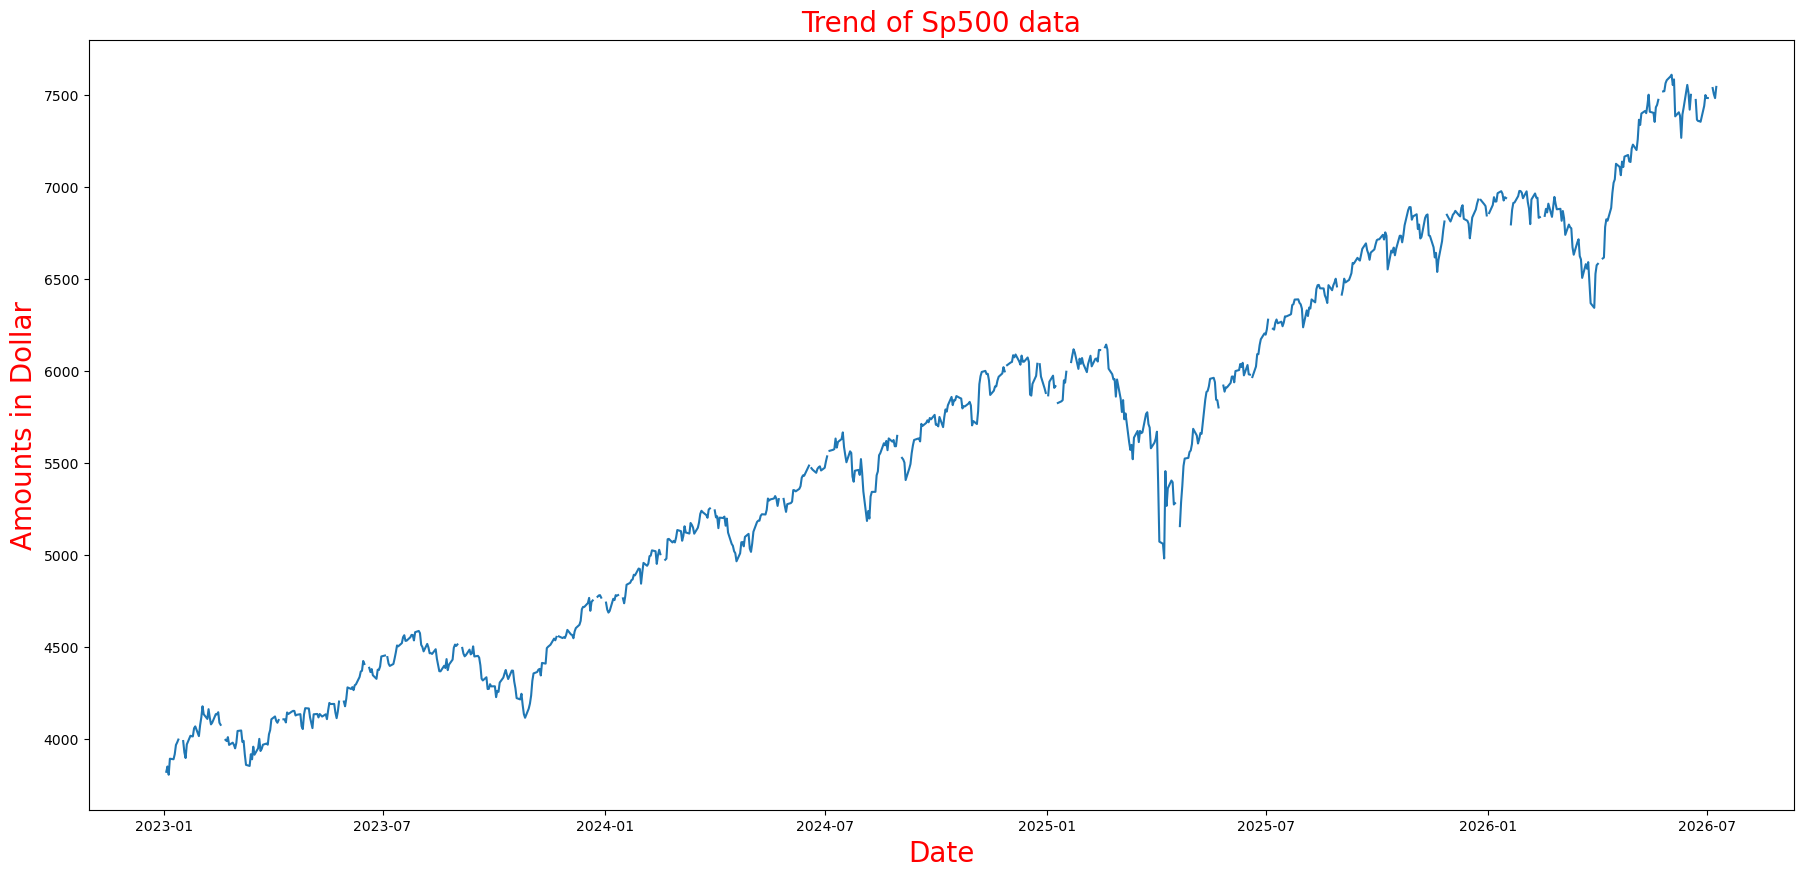

In [34]:
plt.figure(figsize=(22,10))
plt.plot(data["sp500"])
plt.title("Trend of Sp500 data", fontdict={"size":20, "color":"r"})
plt.xlabel("Date",fontdict={"size":20, "color":"r"})
plt.ylabel("Amounts in Dollar",fontdict={"size":20, "color":"r"})
plt.show()

# Using yfinace library

googl, tsla, aapl, amz   (open)

In [ ]:
yf.download("AAPL")

In [ ]:
stock_list=["TSLA","AAPL","AMZN","GOOGL"]
year = 3

In [ ]:
import pandas as pd

In [ ]:
stock_df_price=pd.DataFrame()
for stock in stock_list:
    data = yf.download(stock, period=f'{year}y')
    stock_df_price[stock] = data["Open"]
stock_df_price.head()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


,TSLA,AAPL,AMZN,GOOGL
Date,,,,
2023-07-03,276.489990,191.100906,130.820007,118.191966
2023-07-05,278.820007,188.921502,130.240005,118.191968
2023-07-06,278.089996,187.215377,128.250000,118.747041
2023-07-07,278.429993,188.763680,128.589996,119.044409
2023-07-10,276.470001,186.643403,129.070007,117.260237


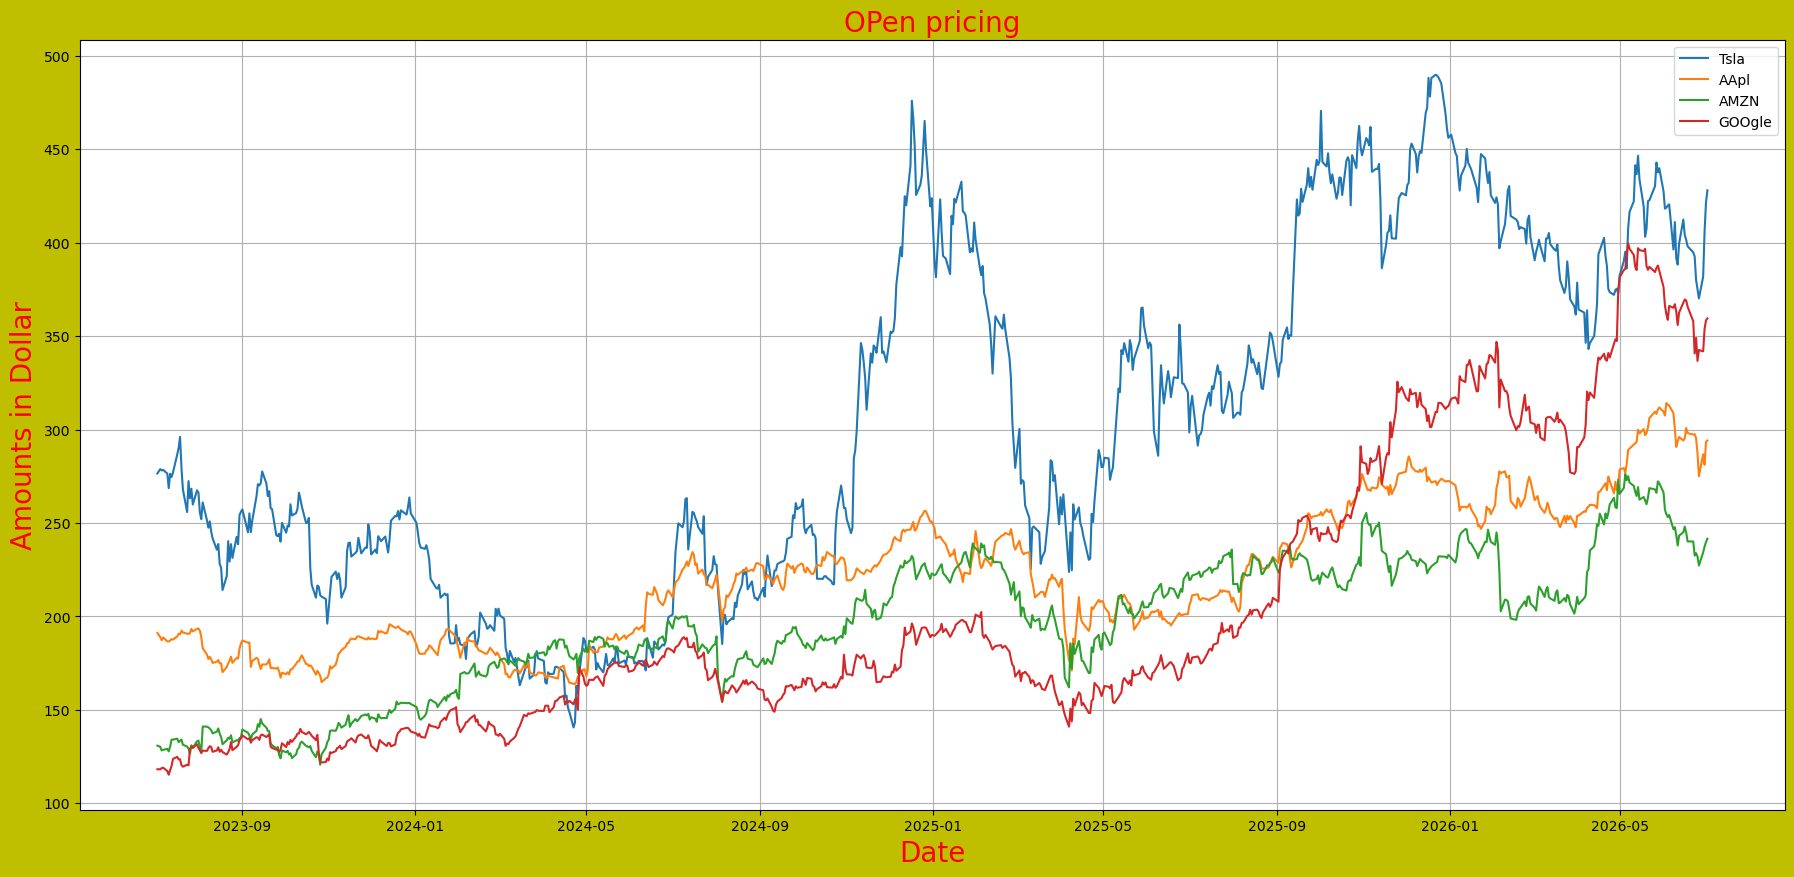

In [ ]:
plt.figure(figsize=(22,10), facecolor="y",edgecolor="r",)
plt.title("OPen pricing",fontdict={"size":20, "color":"r"})
plt.plot(stock_df_price["TSLA"],label = "Tsla")
plt.plot(stock_df_price["AAPL"], label = "AApl")
plt.plot(stock_df_price["AMZN"], label="AMZN")
plt.plot(stock_df_price["GOOGL"], label = "GOOgle")
plt.xlabel("Date",fontdict={"size":20, "color":"r"})
plt.ylabel("Amounts in Dollar",fontdict={"size":20, "color":"r"})
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# functions to plot interactive plotly charts
import plotly.express as px
def interactive_plot(df):
    fig = px.line()
    for i in df.columns:
        fig.add_scatter(x=df.index, y=df[i], name=i)
    fig.update_layout(
         title='Open Pricing ',
         xaxis_title='Date',
         yaxis_title='Amounts',
        width=890,
        margin=dict(l=20, r=20, t=50, b=20),
        legend=dict(
                    orientation="h",
                    yanchor="bottom",
                    y=1.02,
                    xanchor="right",
                    x=1))
    
    return fig

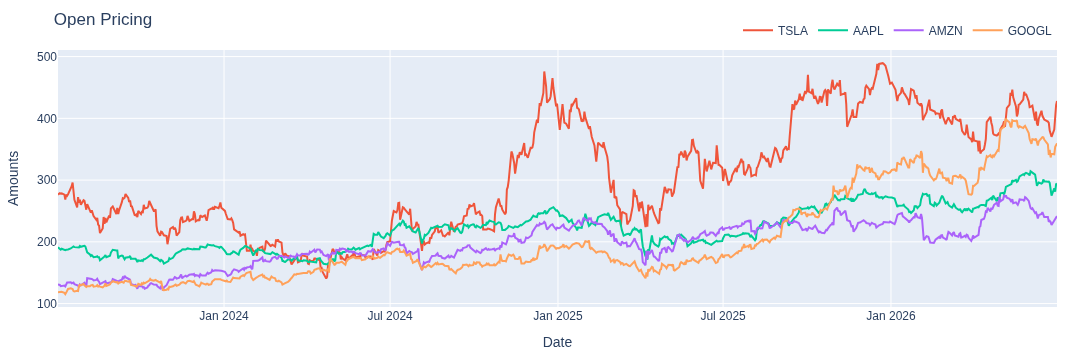

In [ ]:
interactive_plot(stock_df_price)